In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and Prepare Data

In [3]:
cust = pd.read_csv(r"D:\Python Case study\Python Foundation Case Study 2 - Credit Card Case Study\Case Study 2 - Credit Card Case Study\Customer Acqusition.csv")
spend = pd.read_csv(r"D:\Python Case study\Python Foundation Case Study 2 - Credit Card Case Study\Case Study 2 - Credit Card Case Study\spend.csv")
repay = pd.read_csv(r"D:\Python Case study\Python Foundation Case Study 2 - Credit Card Case Study\Case Study 2 - Credit Card Case Study\Repayment.csv")

In [4]:
# 1. In the above dataset,
# a. In case age is less than 18, replace it with mean of age values.
# b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit.
# (customer’s limit provided in acquisition table is the per transaction limit on his card)
# c. Incase the repayment amount is more than the limit, replace the repayment with the
# limit.

In [8]:
cust.head()

,No,Customer,Age,City,Product,Limit,Company,Segment
0,1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed
1,2,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC
2,3,A3,34.0,COCHIN,Platimum,10000.0,C3,Salaried_Pvt
3,4,A4,47.0,BOMBAY,Platimum,10001.0,C4,Govt
4,5,A5,56.0,BANGALORE,Platimum,10002.0,C5,Normal Salary


In [9]:
# a. In case age is less than 18, replace it with mean of age values.
mean_age=cust.loc[cust["Age"]>=18,"Age"].mean()
cust.loc[cust["Age"] < 18,"Age"] = mean_age

In [11]:
# b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit.
df_spend=pd.merge(spend, cust[["Customer", "Limit"]], on="Customer")

df_spend['Amount'] = df_spend.apply(
    lambda x: x['Limit'] * 0.5 if x['Amount'] > x['Limit'] else x['Amount'],
    axis=1
)

In [12]:
# c. Incase the repayment amount is more than the limit, replace the repayment with the limit.
df_repay=pd.merge(repay, cust[["Customer", "Limit"]], on="Customer")

df_repay["Amount"]=df_repay.apply(
    lambda x: x["Limit"] if x["Amount"]>x["Limit"] else x["Amount"], axis=1
)

In [ ]:
# 2. From the above dataset create the following summaries:
# a. How many distinct customers exist?
# b. How many distinct categories exist?
# c. What is the average monthly spend by customers?
# d. What is the average monthly repayment by customers?
# e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month?
# (Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment
# – Monthly spend. Interest is earned only on positive profits and not on negative amounts)
# AnalytixLabs, Website: www.analytixlabs.co.in Email: info@analytixlabs.co.inPhone: (+91) 955.521.9007
# f. What are the top 5 product types?
# g. Which city is having maximum spend?
# h. Which age group is spending more money?

In [13]:
# a. How many distinct customers exist?
cust["Customer"].nunique()

100

In [16]:
# b. How many distinct categories exist?
spend['Type'].nunique()

15

In [17]:
# c. What is the average monthly spend by customers?
spend["Month"]=pd.to_datetime(spend["Month"], format="%d-%b-%y")
spend.groupby(spend["Month"].dt.to_period("M"))["Amount"].mean()

Month
2004-01    251712.068664
2004-02    221215.270000
2004-03    232146.119286
2004-04    235272.037143
2004-05    217539.236429
2004-09    310923.383571
2004-11    270486.397857
2005-01    292741.372857
2005-02    229802.279821
2005-04    252181.326429
2005-05    245696.515429
2005-06    262688.112857
2005-07    229116.663571
2005-08    233734.634286
2005-09    188666.202143
2005-10    194568.640714
2005-11    286143.322857
2005-12    147503.060000
2006-01    282058.006429
2006-02    253858.260714
2006-03    247166.084654
2006-04    232468.967553
2006-05    236162.740357
2006-06    177252.386429
2006-07    287505.098929
2006-08    240699.717143
2006-09    158520.090714
2006-10    236136.335000
2006-11    182841.290000
2006-12    270470.980714
Freq: M, Name: Amount, dtype: float64

In [18]:
# (d) What is the average monthly repayment by customers?

repay["Month"]=pd.to_datetime(repay["Month"], format="%d-%b-%y")
repay.groupby(repay["Month"].dt.to_period("M"))["Amount"].mean()

Month
2004-01    243489.649786
2004-02    256702.630741
2004-03    252585.280667
2004-04    259141.679000
2004-05    226162.720800
2004-09    184487.848750
2004-11    209592.238000
2005-01    240548.098148
2005-02    238829.265123
2005-04    212688.631333
2005-05    263207.367857
2005-06    210199.818333
2005-07    239871.479167
2005-08    264430.921622
2005-09    247700.170000
2005-10    219849.956667
2005-11    256695.120000
2005-12    320379.335833
2006-01    293475.389167
2006-02    284489.565128
2006-03    240851.266814
2006-04    275472.251889
2006-05    256920.884943
2006-06    251990.453333
2006-07    257936.383243
2006-08    224143.992500
2006-09    262533.880833
2006-10    260765.480000
2006-11    199399.197407
2006-12    252736.569167
Freq: M, Name: Amount, dtype: float64

In [19]:
# e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month?
# (Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment – Monthly spend.
# Interest is earned only on positive profits and not on negative amounts)

monthly_spend=spend.groupby(spend["Month"].dt.to_period("M"))["Amount"].sum()
monthly_repay=repay.groupby(repay["Month"].dt.to_period("M"))["Amount"].sum()

monthly_profit=monthly_repay - monthly_spend
# Only positive profit
monthly_profit=monthly_profit.apply(lambda x:x if x > 0 else 0)
bank_profit=monthly_profit * 0.029
bank_profit

Month
2004-01         0.00000
2004-02     21371.36063
2004-03     15623.27266
2004-04     34412.36657
2004-05     75647.04259
2004-09         0.00000
2004-11         0.00000
2005-01         0.00000
2005-02      2423.18026
2005-04         0.00000
2005-05    177956.25221
2005-06         0.00000
2005-07         0.00000
2005-08     93941.85586
2005-09      9601.18109
2005-10         0.00000
2005-11         0.00000
2005-12     51605.76651
2006-01         0.00000
2006-02     12558.33661
2006-03         0.00000
2006-04     85272.17188
2006-05    264683.10237
2006-06     15728.20887
2006-07     43311.59889
2006-08         0.00000
2006-09     27002.63370
2006-10         0.00000
2006-11      7662.44409
2006-12         0.00000
Freq: M, Name: Amount, dtype: float64

In [26]:
# f. What are the top 5 product types?
spend["Type"].value_counts().head(5)

Type
PETRO           200
FOOD            160
CAMERA          160
AIR TICKET      147
TRAIN TICKET    132
Name: count, dtype: int64

In [23]:
spend.columns

Index(['Sl No:', 'Customer', 'Month', 'Type', 'Amount'], dtype='object')

In [32]:
# g. Which city is having maximum spend?
df=pd.merge(spend, cust, on="Customer")
df.groupby("City")["Amount"].sum().idxmax()

'COCHIN'

In [34]:
# h. Which age group is spending more money?
df["Age Group"]=pd.cut(df["Age"], bins=[18, 25, 35, 45, 60])

df.groupby("Age Group")["Amount"].sum()

C:\Users\aakash\AppData\Local\Temp\ipykernel_17228\75736858.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Amount"].sum()


Age Group
(18, 25]    3.091590e+07
(25, 35]    8.665384e+07
(35, 45]    6.433314e+07
(45, 60]    1.173547e+08
Name: Amount, dtype: float64

In [48]:
# i. Who are the top 10 customers in terms of repayment?
df_repay.groupby("Customer")["Amount"].sum().sort_values(ascending=False).head(10).index.tolist()

['A61', 'A60', 'A13', 'A43', 'A45', 'A12', 'A14', 'A44', 'A39', 'A42']

In [50]:
# 3. Calculate the city wise spend on each product on yearly basis. Also include a graphical representation for the same.

df=pd.merge(spend, cust, on="Customer")
df["Years"]=pd.to_datetime(df["Month"]).dt.year

df.groupby(["City","Type", "Years"])["Amount"].sum()

City        Type          Years
BANGALORE   AIR TICKET    2004     1631099.95
                          2005     3212684.48
                          2006     1798555.98
            AUTO          2005      141539.79
                          2006     1251676.54
                                      ...    
TRIVANDRUM  SHOPPING      2005      656352.58
                          2006      655719.75
            TRAIN TICKET  2004      372763.93
                          2005      631977.75
                          2006      378860.48
Name: Amount, Length: 321, dtype: float64

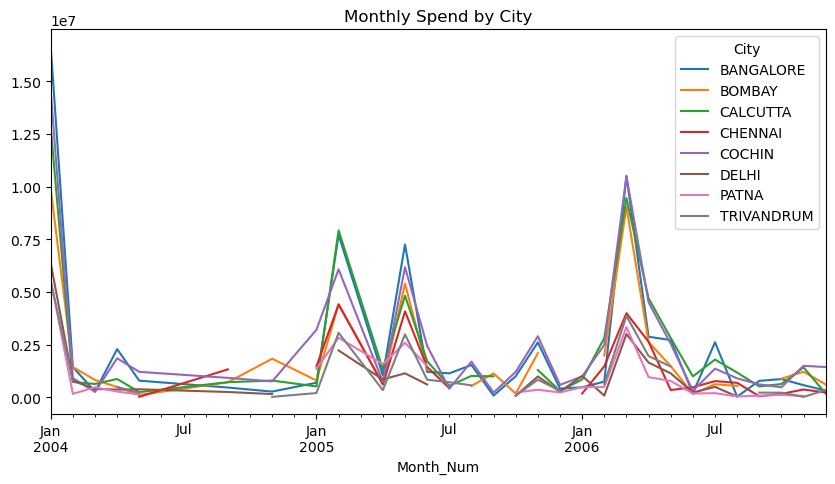

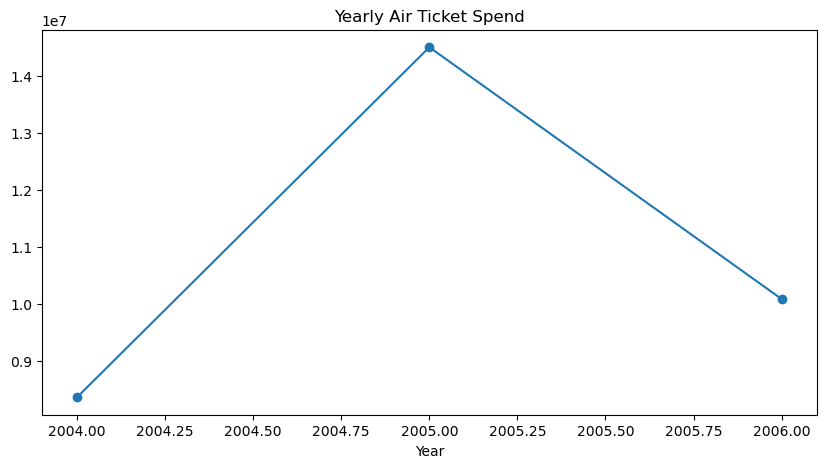

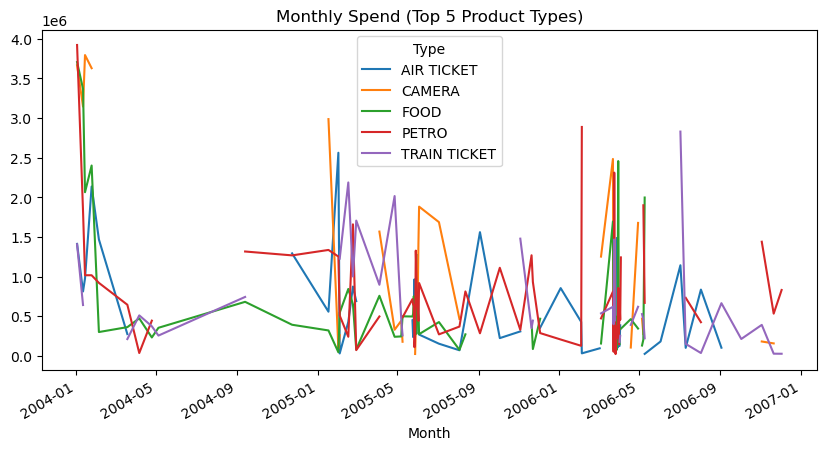

In [66]:
# Monthly spend comparison (city-wise)
df['Month'] = pd.to_datetime(df['Month'])
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.to_period('M')

df.groupby(['Month_Num','City'])['Amount'].sum().unstack().plot(figsize=(10,5))
plt.title("Monthly Spend by City")
plt.show()

# Yearly air ticket spend
# df[df['Type']=="AIR TICKET"].groupby('Years')['Amount'].sum().plot(figsize=(10, 5))
df[df['Type']=="AIR TICKET"].groupby('Year')['Amount'].sum().plot(marker='o', figsize=(10, 5))
plt.title("Yearly Air Ticket Spend")
plt.show()

# Monthly product spend
top_types = df['Type'].value_counts().head(5).index

df[df['Type'].isin(top_types)] \
  .groupby(['Month','Type'])['Amount'] \
  .sum().unstack().plot(figsize=(10,5))

plt.title("Monthly Spend (Top 5 Product Types)")
plt.show()

In [67]:
def top_10_customers(city=None, product=None, time_period="yearly"):
    
    # Merge repayment with customer data
    df = pd.merge(repay, cust, on="Customer")
    
    # Convert Month to datetime
    df["Month"] = pd.to_datetime(df["Month"])
    
    # Filter by product if given
    if product:
        df = df[df["Product"] == product]
    
    # Create time column
    if time_period == "yearly":
        df["Time"] = df["Month"].dt.year
    elif time_period == "monthly":
        df["Time"] = df["Month"].dt.to_period("M")
    
    # Filter by city if given
    if city:
        df = df[df["City"] == city]
    
    # Group and find top 10 customers per city
    result = (
        df.groupby(["City", "Customer"])["Amount"]
        .sum()
        .sort_values(ascending=False)
        .groupby(level=0)
        .head(10)
    )
    
    return result

In [75]:
top_10_customers(product="Silver", time_period="yearly")

City        Customer
BOMBAY      A22         9372561.68
PATNA       A46         7861541.41
BANGALORE   A23         6695551.74
COCHIN      A25         6649292.89
DELHI       A24         5958277.62
BANGALORE   A18         5309969.03
PATNA       A8          5278278.84
BANGALORE   A59         4775019.15
TRIVANDRUM  A57         4726420.73
CALCUTTA    A58         4024959.75
CHENNAI     A9          3886777.18
COCHIN      A7          3820484.02
DELHI       A6          3751463.71
CALCUTTA    A2          2819278.34
BOMBAY      A75          481338.08
            A80          481205.64
PATNA       A84          464121.13
CALCUTTA    A87          462283.02
TRIVANDRUM  A68          424934.75
BANGALORE   A72          327006.94
COCHIN      A74          326559.01
CHENNAI     A96          310992.30
TRIVANDRUM  A86          295851.47
CHENNAI     A85          270527.39
BANGALORE   A76          265619.05
COCHIN      A79          193230.31
CALCUTTA    A73          100712.38
COCHIN      A100          69551.19